8. Brand analysis: analyze the conversation around a particular brand for given dataset

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
import re
from collections import Counter

In [32]:
df = pd.read_csv('CSV/location.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [33]:
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('vader_lexicon')

[nltk_data] Downloading package wordnet to C:\Users\Om
[nltk_data]     Shete\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Om
[nltk_data]     Shete\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\Om
[nltk_data]     Shete\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Om
[nltk_data]     Shete\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package vader_lexicon to C:\Users\Om
[nltk_data]     Shete\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [34]:
stop_words = set(stopwords.words('english'))
sia = SentimentIntensityAnalyzer()

In [35]:
def pre_process(text):
    tokens = word_tokenize(text.lower())
    filtered_tokens = [token for token in tokens if token.isalnum() and token not in stop_words]
    return filtered_tokens

In [36]:
df['tokens'] = df['Text'].apply(pre_process)
df['Sentiment_new'] = df['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour,tokens,Sentiment_new
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12,"[enjoying, beautiful, day, park]",0.750000
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8,"[traffic, terrible, morning]",-1.000000
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15,"[finished, amazing, workout]",0.750000
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18,"[excited, upcoming, weekend, getaway]",0.468750
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19,"[trying, new, recipe, dinner, tonight]",0.136364


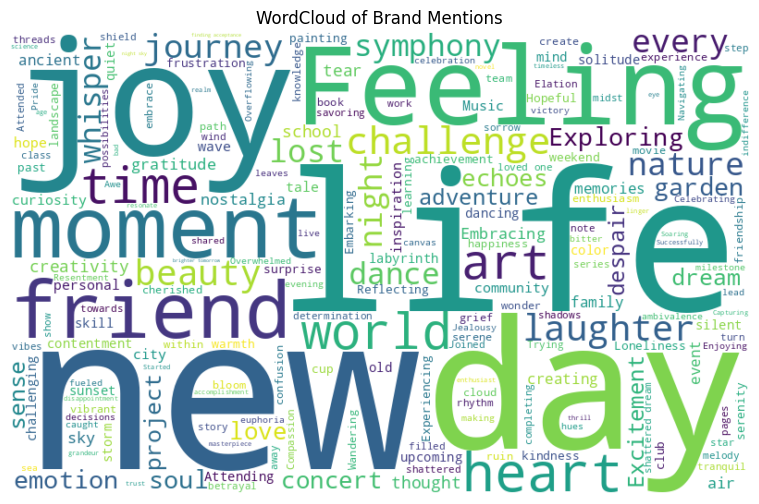

In [37]:
all_text = ' '.join(df['Text'])
wordcloud = WordCloud(width=800, height=500, background_color='white').generate(all_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("WordCloud of Brand Mentions")
plt.axis('off')
plt.show()

In [38]:
average_sentiment = df['Sentiment_new'].mean()
print(f"Average sentiment of brand mentions: {average_sentiment:.2f}")


Average sentiment of brand mentions: 0.10


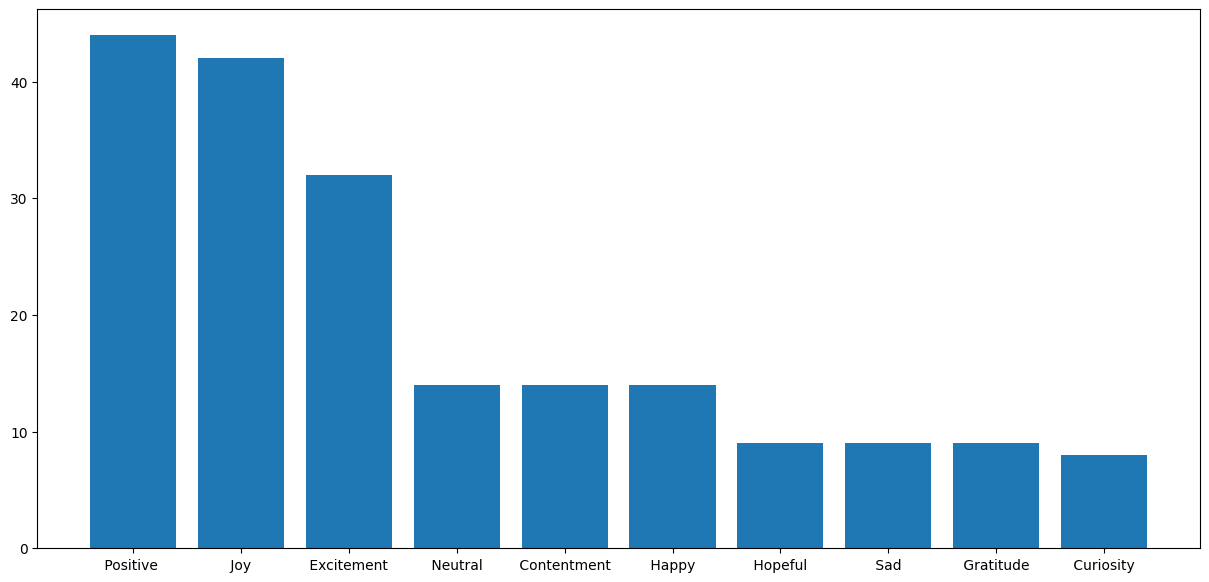

In [42]:
new_df = df['Sentiment'].value_counts().reset_index().head(10)
plt.figure(figsize=(15, 7))
plt.bar(new_df['Sentiment'], new_df['count'])
plt.show()

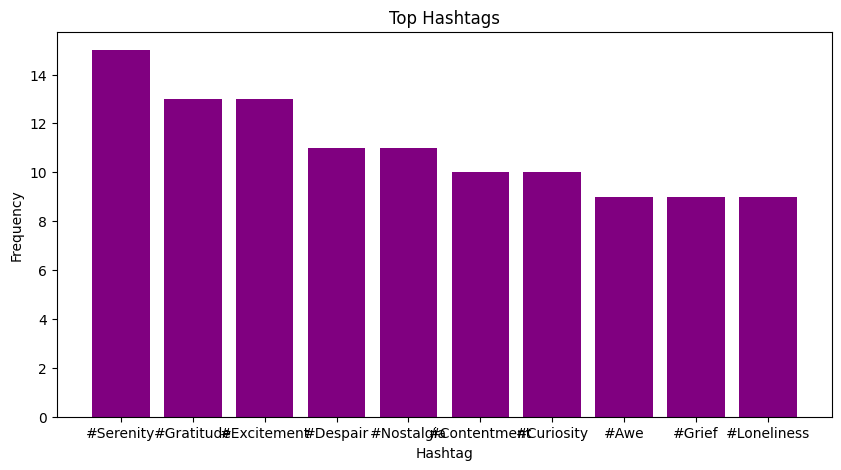

In [46]:
hashtags = []
for text in df['Hashtags'].dropna():
    hashtags.extend(re.findall(r'#\w+', text))

hashtag_ctr = Counter(hashtags).most_common(10)
tags, ctr = zip(*hashtag_ctr)

plt.figure(figsize=(10, 5))
plt.bar(tags, ctr, color='purple')
plt.title(f"Top Hashtags")
plt.xlabel('Hashtag')
plt.ylabel('Frequency')
plt.show()

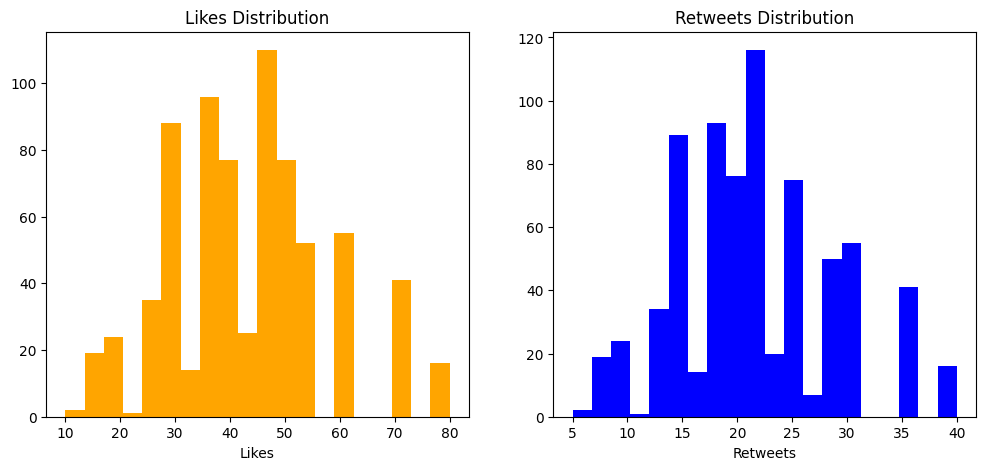

In [49]:
plt.figure(figsize=(12, 5))

# Likes
plt.subplot(1, 2, 1)
plt.hist(df['Likes'].dropna(), bins=20, color='orange')
plt.title(f"Likes Distribution")
plt.xlabel('Likes')

# Retweets
plt.subplot(1, 2, 2)
plt.hist(df['Retweets'].dropna(), bins=20, color='blue')
plt.title(f"Retweets Distribution")
plt.xlabel('Retweets')

plt.show()
